In [655]:
import numpy as np

In [656]:
class LinearRegressor:
    def __init__(self, max_iterations=1000, learning_rate=0.01, alpha = 0.5, regularization = None):
        self.max_iterations = max_iterations
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.alpha = alpha
        self.w = None           
        self.b = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.n_samples, self.n_features = X.shape

        self.w = np.zeros(self.n_features)
        self.b = 0

        if self.regularization == 'L1':
            self.regularization_f = lambda w, alpha: alpha * np.sign(w)
        elif self.regularization == 'L2':
            self.regularization_f = lambda w, alpha: alpha * 2 * w
        else:
            self.regularization_f = lambda w, alpha: 0


        for _ in range(self.max_iterations):
            y_pred = X.dot(self.w) + self.b
            error = y_pred - y

            dw = (2 / self.n_samples) * X.T.dot(error) + self.regularization_f(self.w, self.alpha)
            db = 2/self.n_samples * np.sum(error) 

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        X = np.array(X)
        return X.dot(self.w) + self.b
        

In [657]:
import matplotlib.pyplot as plt

## Тесты на сгенерированных данных

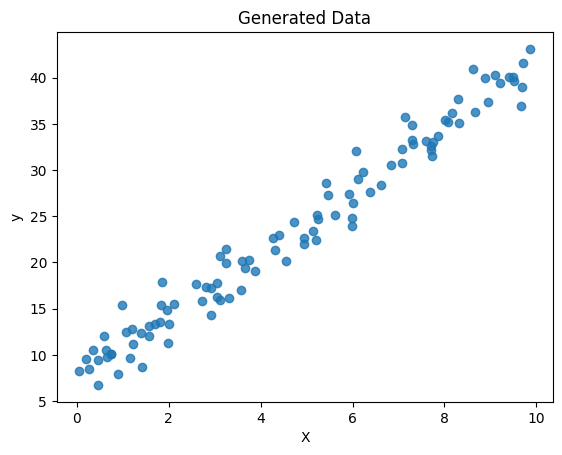

In [658]:
np.random.seed(42)
X = np.random.rand(100, 1) * 10  

true_w = 3.5
true_b = 7.0

y = true_w * X[:, 0] + true_b + np.random.randn(100) * 2  

plt.scatter(X, y, alpha=0.8)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Data')
plt.show()

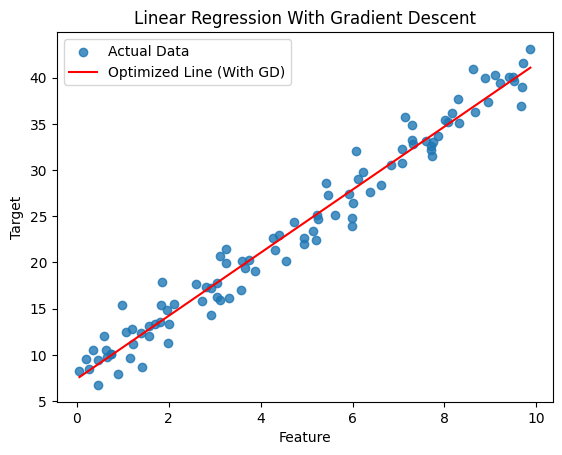

In [659]:
lr = LinearRegressor()
lr.fit(X, y)

X_line = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_line = lr.predict(X_line)

plt.scatter(X, y, label='Actual Data', alpha=0.8)
plt.plot(X_line, y_line, color='red', label='Optimized Line (With GD)')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Linear Regression With Gradient Descent')
plt.legend()
plt.show()

## Тесты на датасете

In [660]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [661]:
data = pd.read_csv('../data/processed_trip_duration.csv')
data.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,in_nyc_center?,distance,hour_1,hour_2,...,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,hour_24,is_it_weekday?,is_it_first_vendor?(else 2nd)
0,1,-73.953918,40.778873,-73.963875,40.771164,400,1,1199.769914,1,0,...,0,0,0,0,0,0,0,0,1,0
1,2,-73.988312,40.731743,-73.994751,40.694931,1100,1,4123.945168,0,1,...,0,0,0,0,0,0,0,0,1,1
2,2,-73.997314,40.721458,-73.948029,40.774918,1635,1,7250.435807,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,-73.961670,40.759720,-73.956779,40.780628,1141,1,2358.286547,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2,-73.993614,40.751884,-73.995422,40.723862,1455,1,3115.641570,0,0,...,0,0,0,0,0,0,0,0,0,0


In [662]:
X = data.drop(['trip_duration'], axis=1)
y = data['trip_duration']

In [663]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [664]:
from sklearn.preprocessing import StandardScaler

In [665]:
scaler = StandardScaler()

In [666]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [667]:
lr = LinearRegressor(learning_rate=0.01, alpha=0.1, max_iterations=1000)

In [668]:
lr.fit(X_train, y_train)

In [669]:
y_pred = lr.predict(X_test)

In [670]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [671]:
print('MAE', mae)
print('R^2', r2)

MAE 228.33155711407105
R^2 0.5814535304538473
